In [1]:
import sys
import os

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import sys
import os

%cd /content
!rm -rf /content/BTL_ML
!git clone https://github.com/VinhDoan1604/BTL_ML

%cd /content/BTL_ML
project_path = os.getcwd()
if project_path not in sys.path:
    sys.path.append(project_path)

# !pip install -r requirements.txt
print("\n" + "="*40)
print("Thư mục hiện tại:", os.getcwd())
print("Danh sách file/thư mục:")
!ls

/content
Cloning into 'BTL_ML'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 79 (delta 32), reused 33 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 1.99 MiB | 5.51 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/BTL_ML

Thư mục hiện tại: /content/BTL_ML
Danh sách file/thư mục:
features  modules  notebooks  README.md  reports


In [3]:
!pip install "transformers<5.0.0" tf-keras tensorflow sentence-transformers torch langdetect emoji wordcloud

In [4]:
!pip install --upgrade nltk

In [5]:
import nltk

# Tải các gói dữ liệu cần thiết cho NLP của bạn
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

os.environ["TF_USE_LEGACY_KERAS"] = "1" # Keras 2 cho HuggingFace BERT

import string
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud

import re
import emoji
from langdetect import detect, LangDetectException, DetectorFactory
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

DetectorFactory.seed = 0

from scipy.stats import spearmanr
from scipy.sparse import hstack, csr_matrix

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import tensorflow as tf
import tf_keras
from tf_keras.models import Sequential
from tf_keras.layers import Input, LSTM, SimpleRNN, Dense, Dropout, Embedding, TextVectorization
from tf_keras.callbacks import EarlyStopping

from sentence_transformers import SentenceTransformer
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer

from modules.cleaning import *
from modules.preprocessing import *
from modules.eda import *
from modules.models import *

In [7]:
import tensorflow as tf
import torch

tf_gpus = tf.config.list_physical_devices('GPU')
if tf_gpus:
    print(f"TENSORFLOW: Đã tìm thấy GPU.")
    try:
        for gpu in tf_gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Đã kích hoạt Memory Growth cho TensorFlow.")
    except RuntimeError as e:
        print("Lỗi khi cấu hình Memory Growth:", e)
else:
    print("TENSORFLOW: Không có GPU. Đang chạy bằng CPU.")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"PYTORCH: Đã tìm thấy GPU ({gpu_name}).")
else:
    print("PYTORCH: Không có GPU. Đang chạy bằng CPU.")

TENSORFLOW: Đã tìm thấy GPU.
Đã kích hoạt Memory Growth cho TensorFlow.
PYTORCH: Đã tìm thấy GPU (Tesla T4).


In [8]:
import kagglehub
shymammoth_shopee_reviews_path = kagglehub.dataset_download('shymammoth/shopee-reviews')

print('Data source import complete.')


Using Colab cache for faster access to the 'shopee-reviews' dataset.
Data source import complete.


# Loading data

In [9]:
DATA_PATH = shymammoth_shopee_reviews_path + "/shopee_reviews.csv"

print("Loading dataset...")
df = pd.read_csv(DATA_PATH)

# Randomly sample 100,000 rows
df = df.sample(frac=100_000/len(df), random_state=42).reset_index(drop=True)

print(f"Sampled dataset shape: {df.shape}")

Loading dataset...
Sampled dataset shape: (100000, 2)


In [10]:
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'label'

# Cleaning data

## Resolving Data Type Heterogeneity in Target Labels ##

In [11]:
print("="*45)
print("-------- Unique labels --------")
print(df[LABEL_COLUMN].value_counts())
print("="*45)
print("-------- Checking types --------")
print(df[LABEL_COLUMN].apply(type).value_counts())
print("="*45)

-------- Unique labels --------
label
5        75742
5        11213
4         5823
3         2715
1         1674
2         1101
4          901
3          433
1          255
2          142
label        1
Name: count, dtype: int64
-------- Checking types --------
label
<class 'int'>    87055
<class 'str'>    12945
Name: count, dtype: int64


In [12]:
df = clean_and_convert_labels(df)

--- Unique values in 'label' before conversion ---
label
5        75742
5        11213
4         5823
3         2715
1         1674
2         1101
4          901
3          433
1          255
2          142
label        1
Name: count, dtype: int64
Non-numeric values found: ['label']

Final Data Type: int64
--- Unique values in 'label' after conversion ---
label
5    86955
4     6724
3     3148
1     1929
2     1243
Name: count, dtype: int64


--- [STATUS] Initializing Full-Scale Corpus Analysis ---


Identifying Languages:   0%|          | 0/99999 [00:00<?, ?it/s]

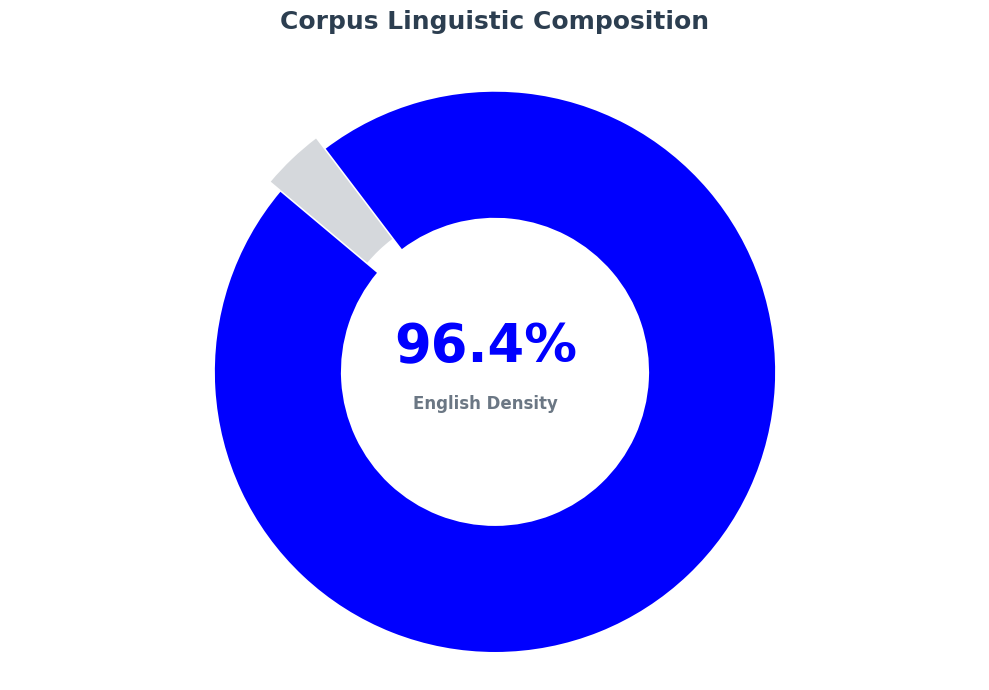


[ACTION] English dominance detected (> 90.0%). Isolating primary corpus...
Filtration successful. Current Dimension: 96440 rows.
[CLEANUP] Internal feature 'lang' decommissioned.
--- [STATUS] Pipeline Execution Completed ---


In [13]:
DetectorFactory.seed = 42
tqdm.pandas(desc="Identifying Languages")

print("--- [STATUS] Initializing Full-Scale Corpus Analysis ---")
original_row_count = len(df)

# 1. Processing: Language identification on the entire Dataset
# We skip the sampling step to ensure the integrity of the input data
df['lang'] = df['text'].fillna('').astype(str).progress_apply(identify_language)

# 2. Statistical Distribution: Calculate distribution ratio
lang_stats = df['lang'].value_counts(normalize=True).mul(100).round(2)
en_ratio = lang_stats.get('en', 0)
others_ratio = 100 - en_ratio

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)

# Draw Donut chart
wedges, _ = ax.pie(
    [en_ratio, others_ratio],
    colors=['blue', '#D5D8DC'], # Changed color from colors[0] to 'blue'
    startangle=140,
    wedgeprops={'width': 0.45, 'edgecolor': 'w', 'linewidth': 0},
    explode=(0.05, 0)
)

# Add KPI to the center of the circle (Central Metric)
ax.text(0, 0.05, f"{en_ratio:.1f}%", ha='center', va='center',
        fontsize=38, fontweight='bold', color='blue') # Changed color from colors[0] to 'blue'
ax.text(0, -0.15, "English Density", ha='center', va='center',
        fontsize=12, color='#2C3E50', fontweight='semibold', alpha=0.7)

# Title and In-depth Description (Description)
plt.title('Corpus Linguistic Composition', fontsize=18, pad=25, fontweight='bold', color='#2C3E50')

plt.axis('equal')
plt.tight_layout()
plt.show()

# 4. Automated Filtration: Filter data based on statistical threshold
STRICT_THRESHOLD = 90.0
is_dominant = en_ratio > STRICT_THRESHOLD

if is_dominant:
    print(f"\n[ACTION] English dominance detected (> {STRICT_THRESHOLD}%). Isolating primary corpus...")
    df = df[df['lang'] == 'en'].reset_index(drop=True)
    print(f"Filtration successful. Current Dimension: {len(df)} rows.")
else:
    print(f"\n[OBSERVATION] Multilingual distribution detected. Maintaining 'lang' feature for stratified analysis.")

# Memory cleanup: Remove intermediate column after Feature Engineering is complete
if 'lang' in df.columns:
    df = df.drop('lang', axis=1)
    print("[CLEANUP] Internal feature 'lang' decommissioned.")

print("--- [STATUS] Pipeline Execution Completed ---")

In [14]:
X_train, X_test, y_train, y_test = perform_train_test_split(df, LABEL_COLUMN, test_size=0.20, random_state=42)

# EDA

In [15]:
df_eda = X_train.copy()
df_eda[LABEL_COLUMN] = y_train.copy()

In [16]:
print("="*45)
print("Shape:", df.shape)

print("="*45)
print("Columns:", df.columns.tolist())

print("="*45)
print(f'Dtypes:\n{df.dtypes}')

print("="*45)
print(f'Info:')
df.info()

print("="*45)
print(f'Null values:\n{df.isnull().sum()}')

print("="*45)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate texts:", df['text'].duplicated().sum())

print("="*45)
print("Sample:")
df_eda.head(10)

Shape: (96440, 2)
Columns: ['label', 'text']
Dtypes:
label     int64
text     object
dtype: object
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96440 entries, 0 to 96439
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   96440 non-null  int64 
 1   text    96440 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.5+ MB
Null values:
label    0
text     0
dtype: int64
Duplicate rows: 0
Duplicate texts: 0
Sample:


,text,label
51368,Nice and really can fit my 10mnth and 5yr old....,5
89524,"Bought 3 masks, navy mask is dirty, burgundy m...",3
25553,Item received in good packaging and condition....,5
28195,Quality is very good for price paid. Will defi...,5
1457,Love this casing and the strap! Very useful wh...,5
35397,"Rather fast delivery, ordered on 15jan, receiv...",5
43266,Looks good. Magnet is strong too! Has the adhe...,5
8625,Good product and worth the money to pay for. D...,5
9913,"Received it fast! Yet to try, cant wait to try...",5
64405,Ordered on 23 Mar and received on 27 Mar. Deli...,5


In [17]:
LABEL_ORDER = sorted(df['label'].unique())
LABEL_COUNT= len(LABEL_ORDER)

theme_palette='inferno'
colors = sns.color_palette(theme_palette, LABEL_COUNT).as_hex()

print(LABEL_ORDER)

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## Target Class Frequency & Prevalence Profiling ##

Total  count:  77152


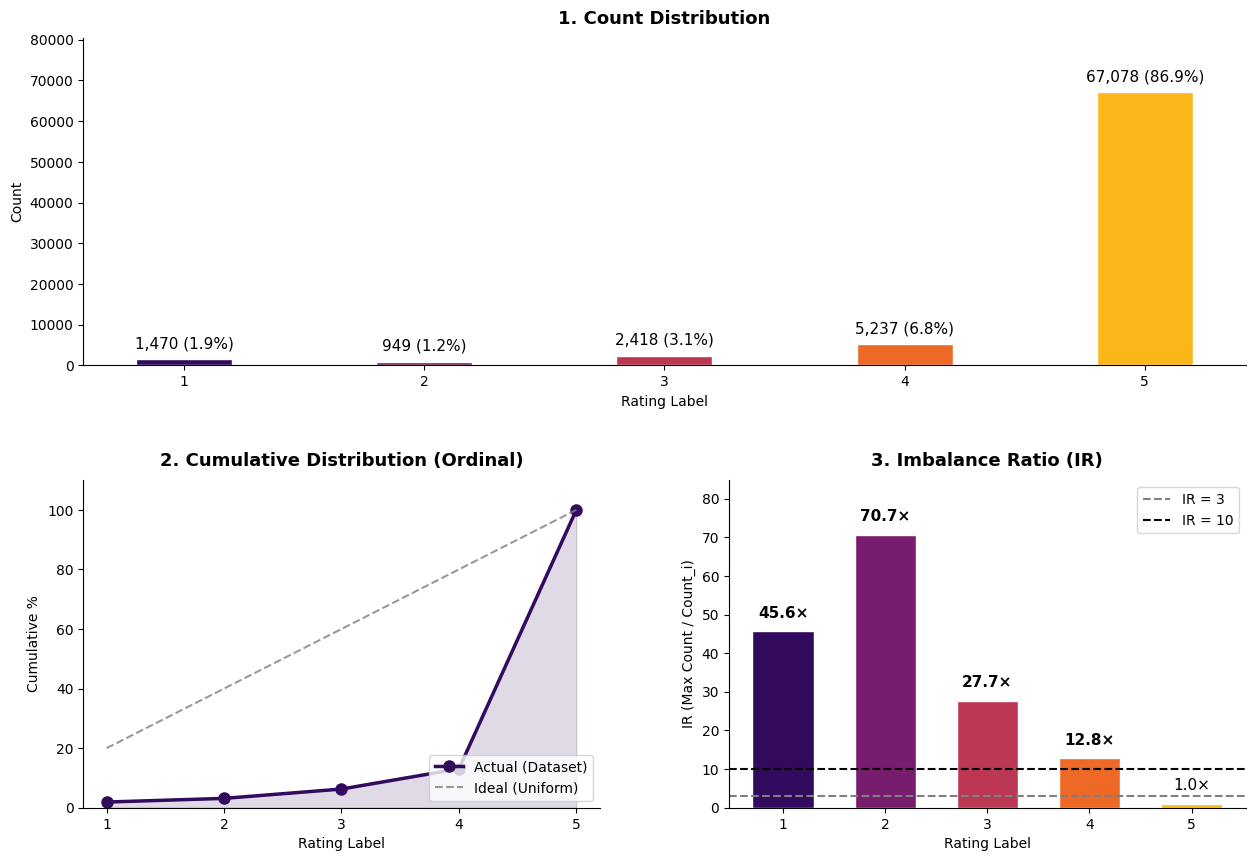

In [18]:
plot_label_distribution(df_eda, LABEL_COLUMN, LABEL_ORDER, colors, theme_palette)

## Quantitative Textual Patterns ##

In [19]:
df_eda=create_text_features(df_eda)

Feature extraction completed successfully.


In [20]:
df.head(10)

,label,text
0,5,Love these masks and samples given. Will try o...
1,5,Good value for 300g tube. Thank you !
2,5,Ordered a Size 12 but came a Size 9 so I’m not...
3,5,Ordered on 3/11/19 received item in good condi...
4,5,Super comfy.....love it.....
5,5,Item was in great condition. Super fast delive...
6,5,Good fast and efficient.. recommended.
7,4,difficult to apply on phone due to many air bu...
8,4,"It’s not a silent keyboard, the letter “T” is ..."
9,5,It is worth the money! And delivered within th...


In [21]:
features=['n_words', 'num_emoji', 'upper_ratio']

## Quantitative Analysis of Review Length ##

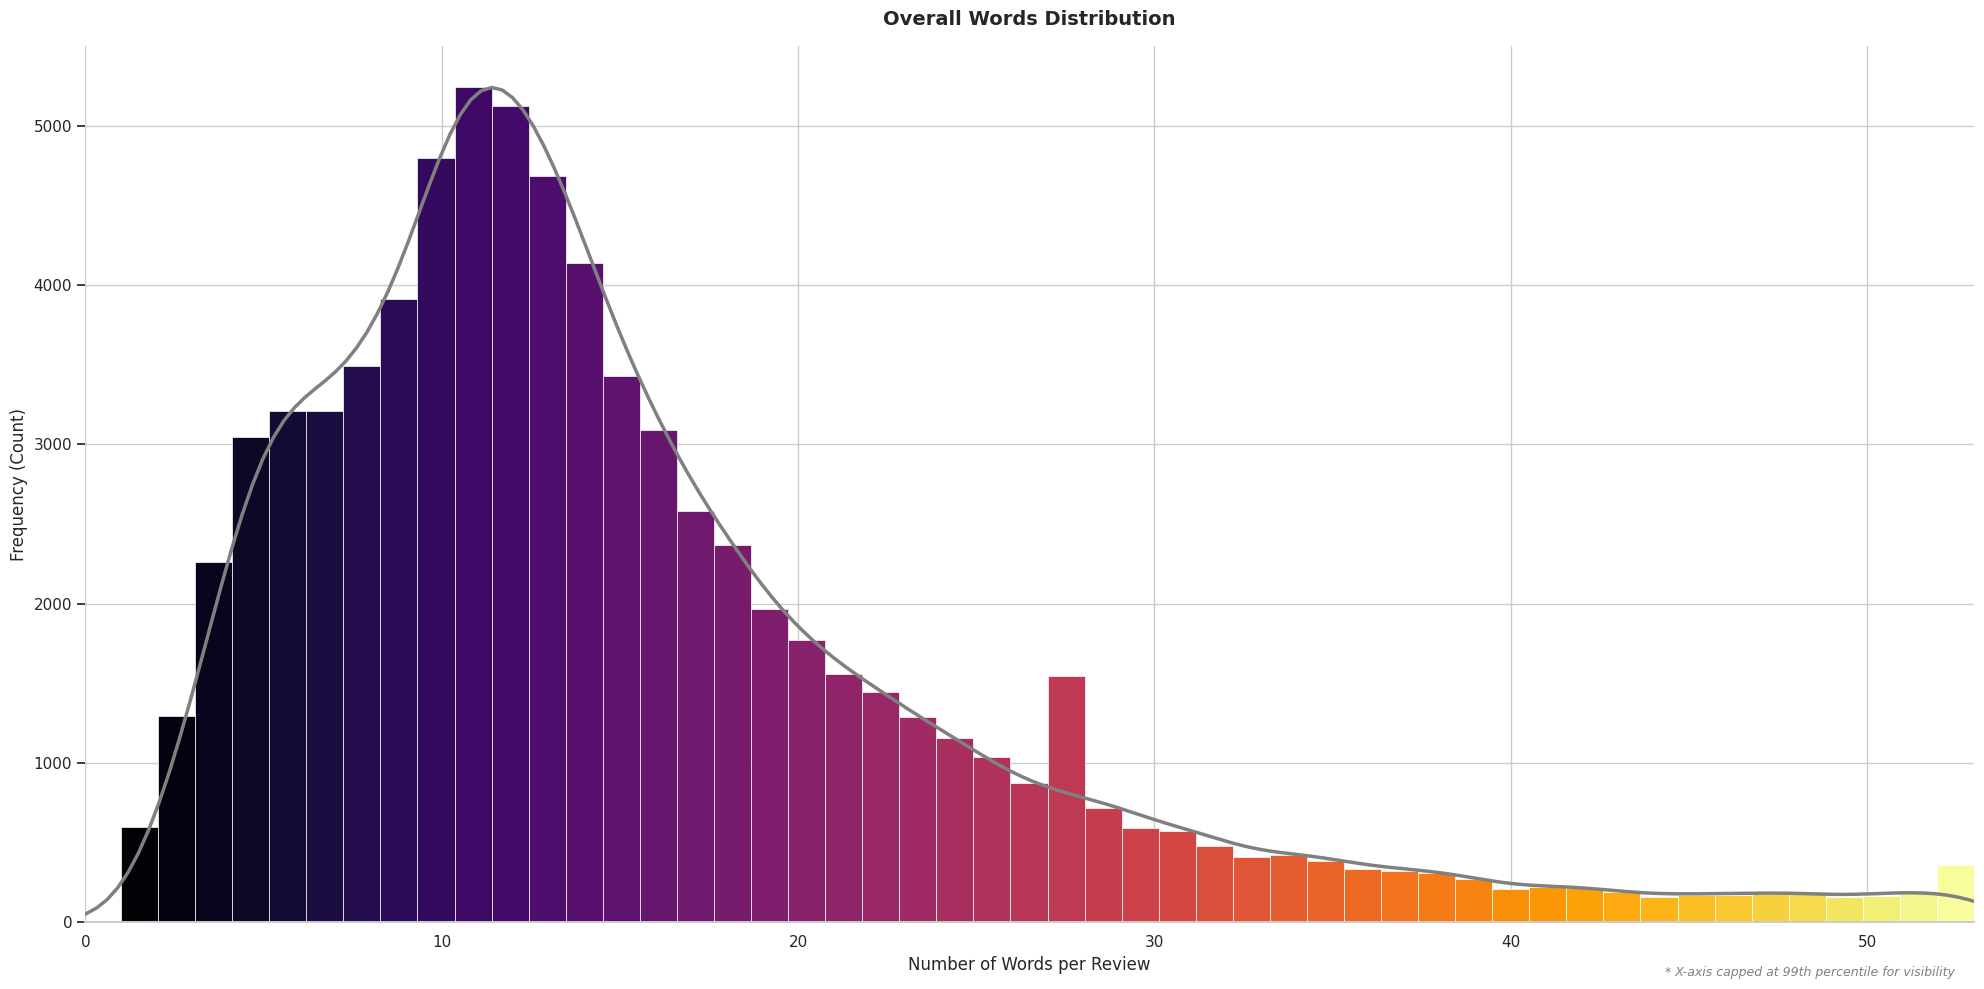

In [22]:
# Call the new function for 'n_words' and 'n_chars'
plot_overall_text_features_distribution(df_eda, ['n_words'], theme_palette)

## Across Labels

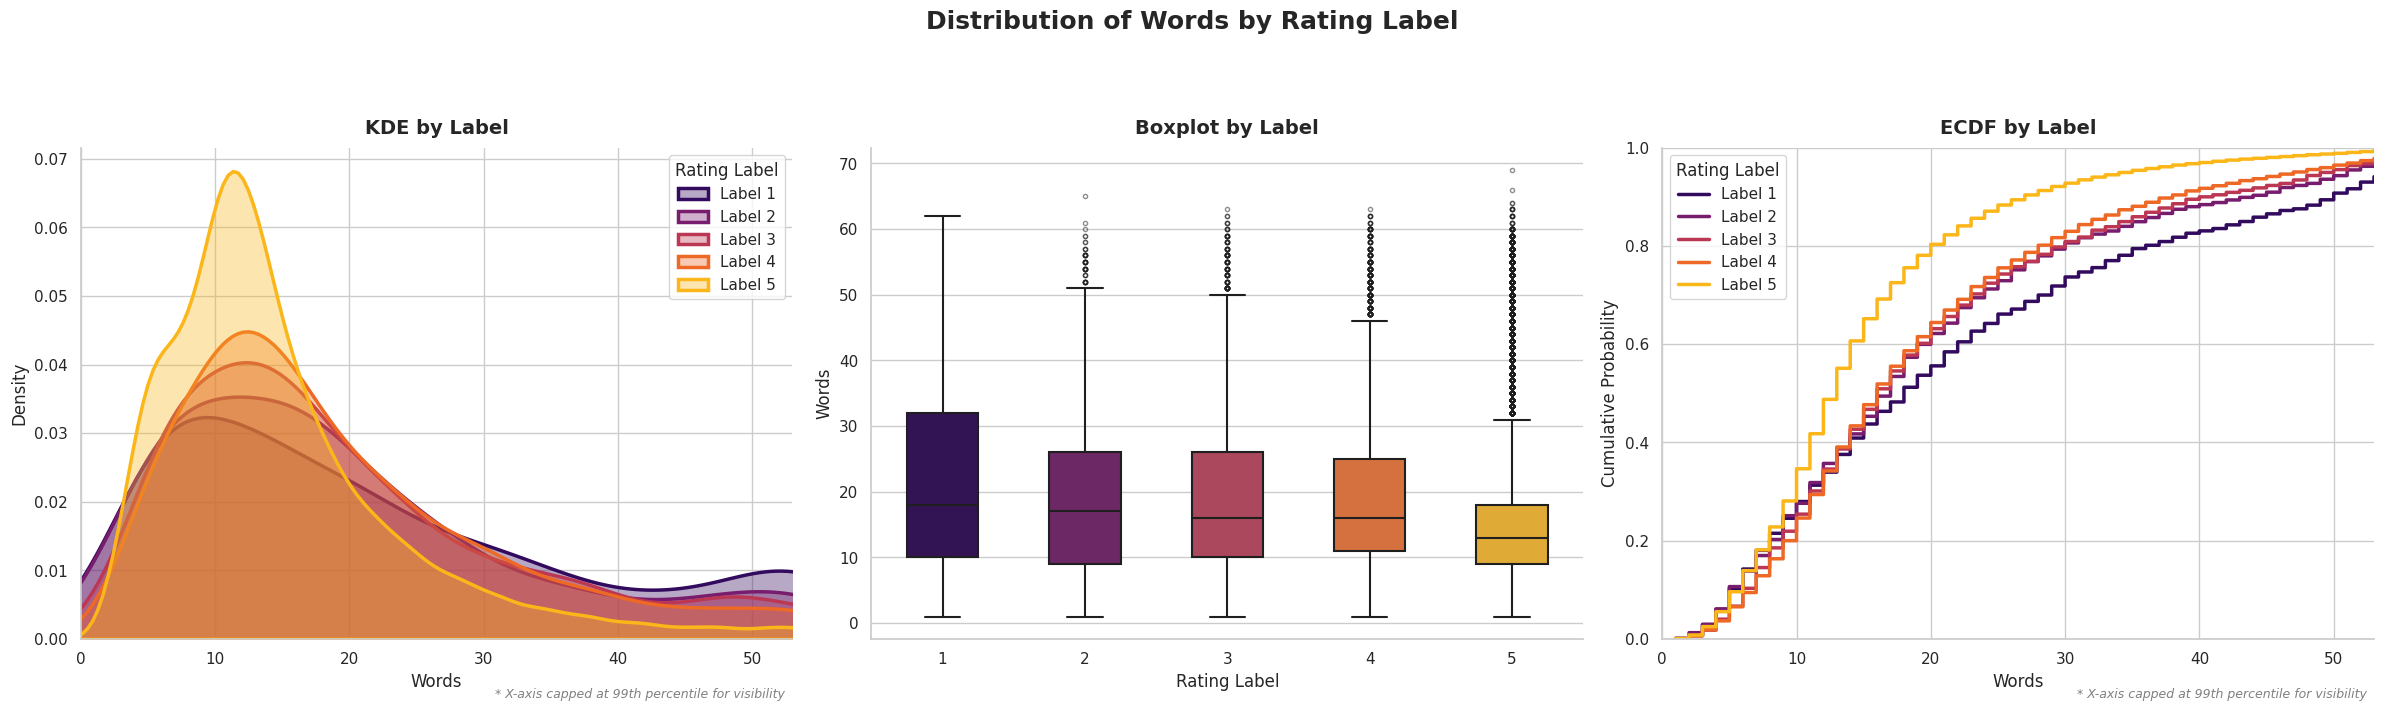

In [23]:
# --- Call the new combined plotting function for 'n_words' ---
plot_feature_distributions_by_label(
    df=df_eda,
    feature_col='n_words',
    label_column=LABEL_COLUMN,
    label_order=LABEL_ORDER,
    theme_palette=theme_palette
)

In [24]:
# Call the new function with your dataframe and relevant variables
print_detailed_statistics_by_label(df_eda, LABEL_COLUMN, ['n_words'])


--- Detailed Statistics per Rating Label (n_words & n_chars) ---

--- Words Statistics ---
        mean  median  min  max    std
label                                
1      22.43    18.0    1   62  15.82
2      20.17    17.0    1   65  13.96
3      20.02    16.0    1   63  13.31
4      19.48    16.0    1   63  12.49
5      15.02    13.0    1   69   9.54




## Emoji ##

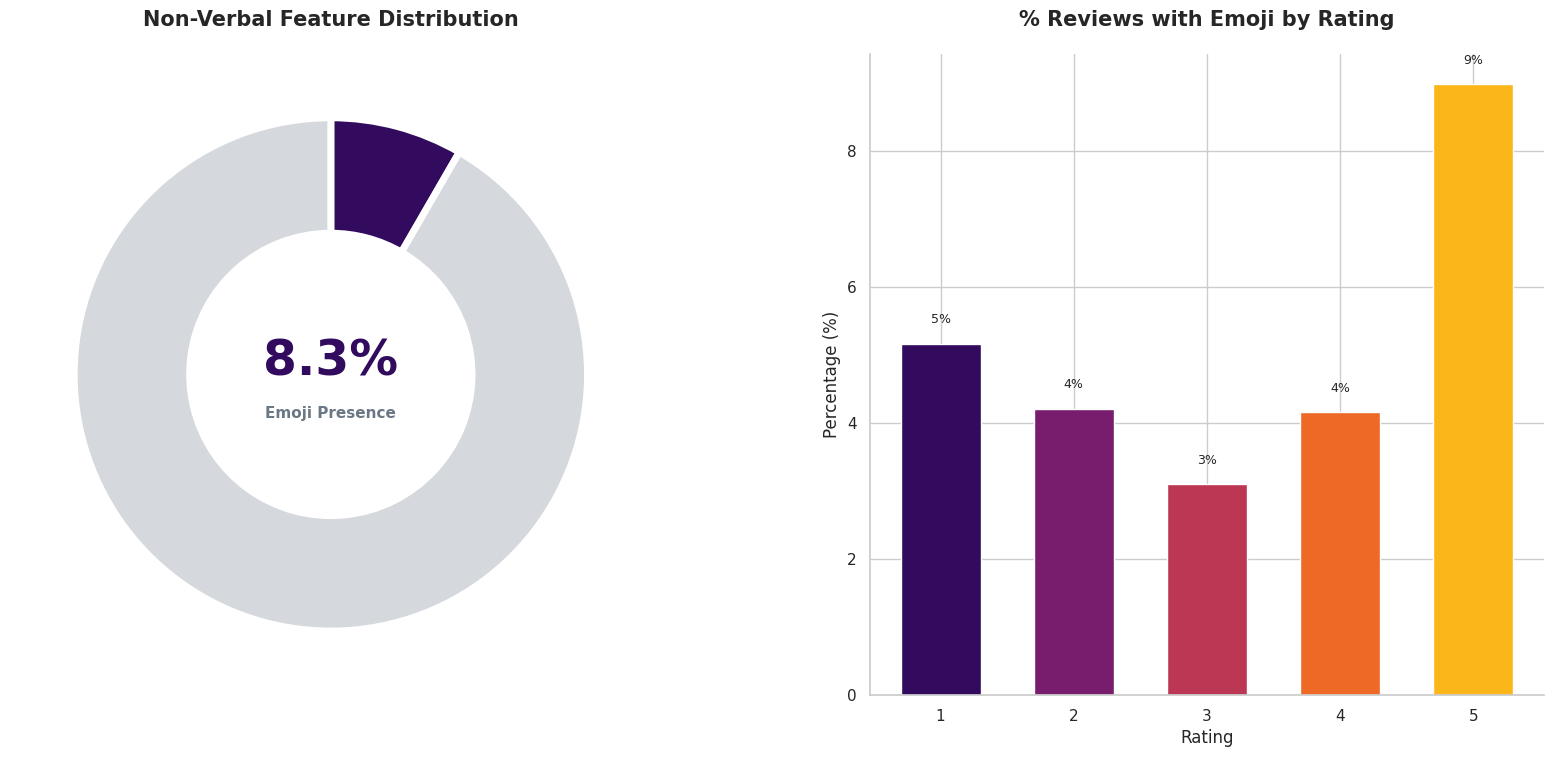

In [25]:
plot_emoji_analysis(df_eda, TEXT_COLUMN, LABEL_COLUMN, LABEL_ORDER, colors)

# Preprocessing

In [26]:
X_train_features = create_text_features(X_train, text_col='text')
X_test_features = create_text_features(X_test, text_col='text')

Feature extraction completed successfully.
Feature extraction completed successfully.


In [27]:
# Initialize Lemmatizer (Should be outside the function to avoid reloading multiple times, which speeds up apply operations on DataFrame)
lemmatizer = WordNetLemmatizer()

X_train_features['processed_text'] = X_train_features[TEXT_COLUMN].apply(preprocess_and_tokenize)
X_test_features['processed_text'] = X_test_features[TEXT_COLUMN].apply(preprocess_and_tokenize)

In [28]:
df_eda = X_train_features.copy()
df_eda['label'] = y_train

## Global top words ##

EDA: GLOBAL BAG OF WORDS FREQUENCY


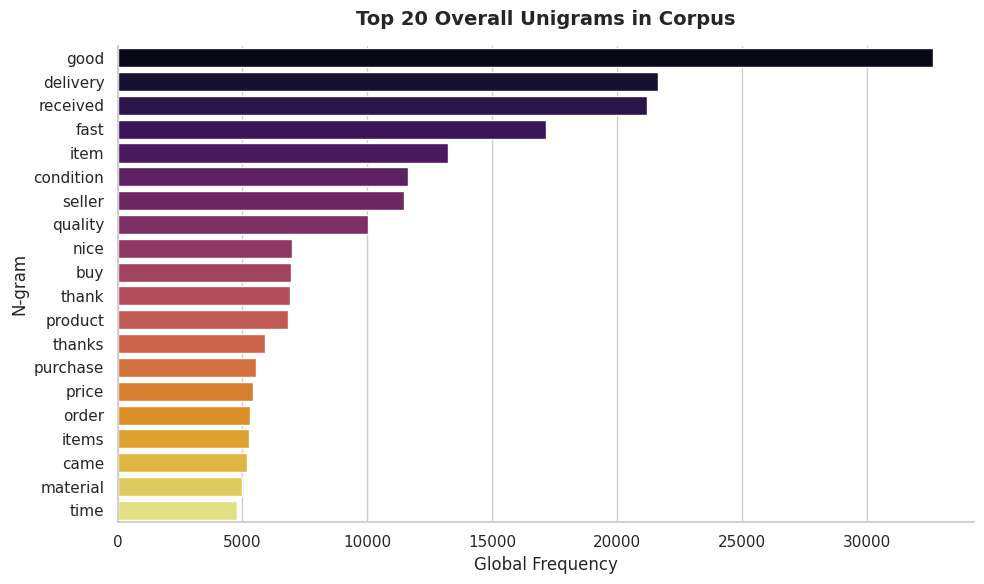

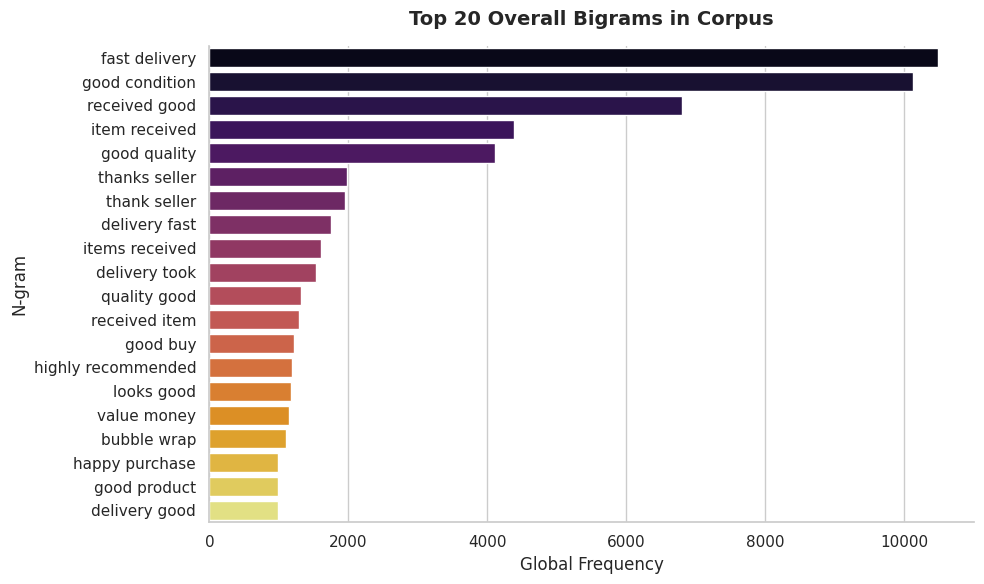

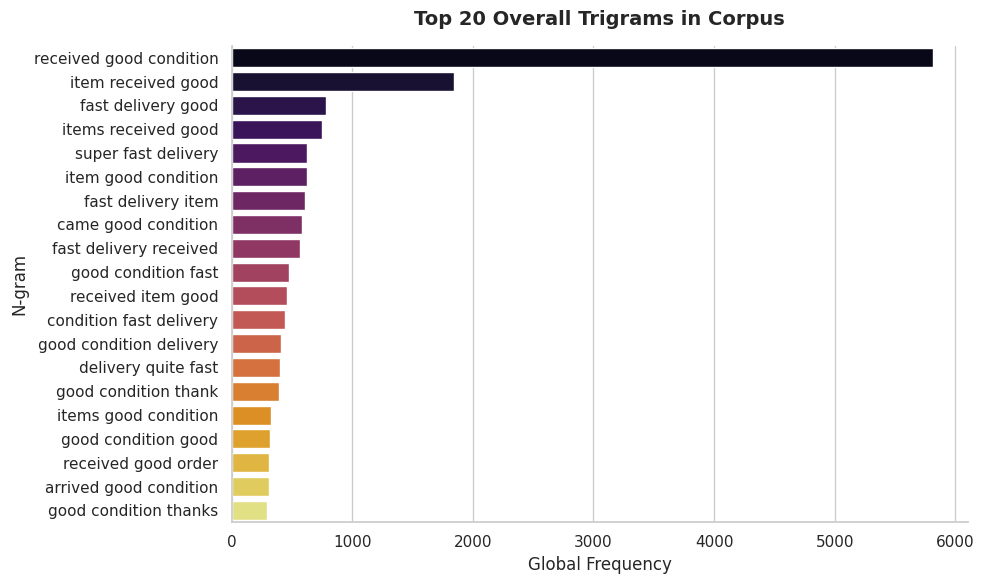

In [29]:
print("="*50)
print("EDA: GLOBAL BAG OF WORDS FREQUENCY")
print("="*50)

# Unigram
plot_overall_top_words(df_eda, 'processed_text', top_n=20, ngram_range=(1, 1), title="Unigrams")

# Bigram
plot_overall_top_words(df_eda, 'processed_text', top_n=20, ngram_range=(2, 2), title="Bigrams")

# Trigram
plot_overall_top_words(df_eda, 'processed_text', top_n=20, ngram_range=(3, 3), title="Trigrams")

## Class-Specific Top Words

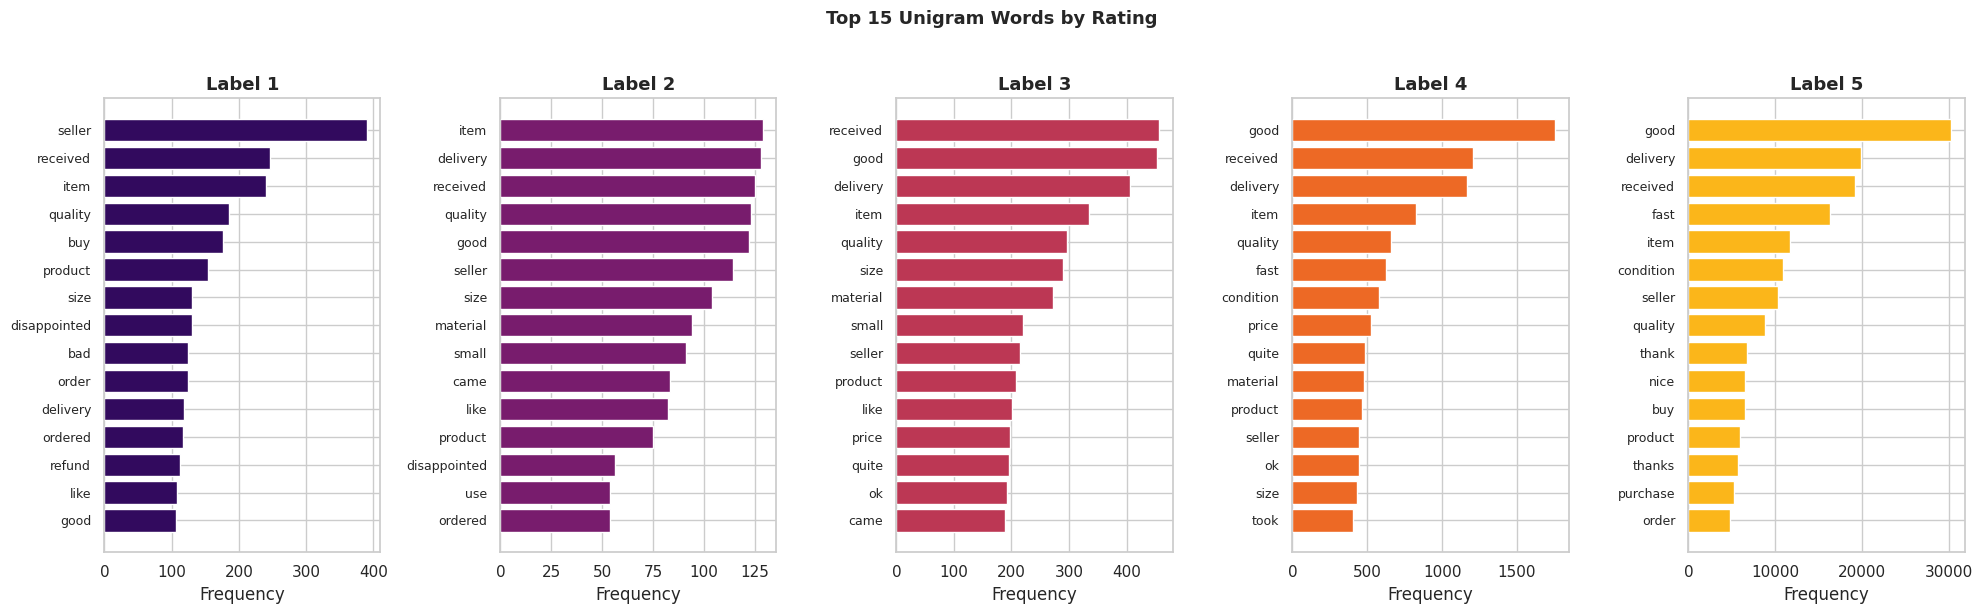

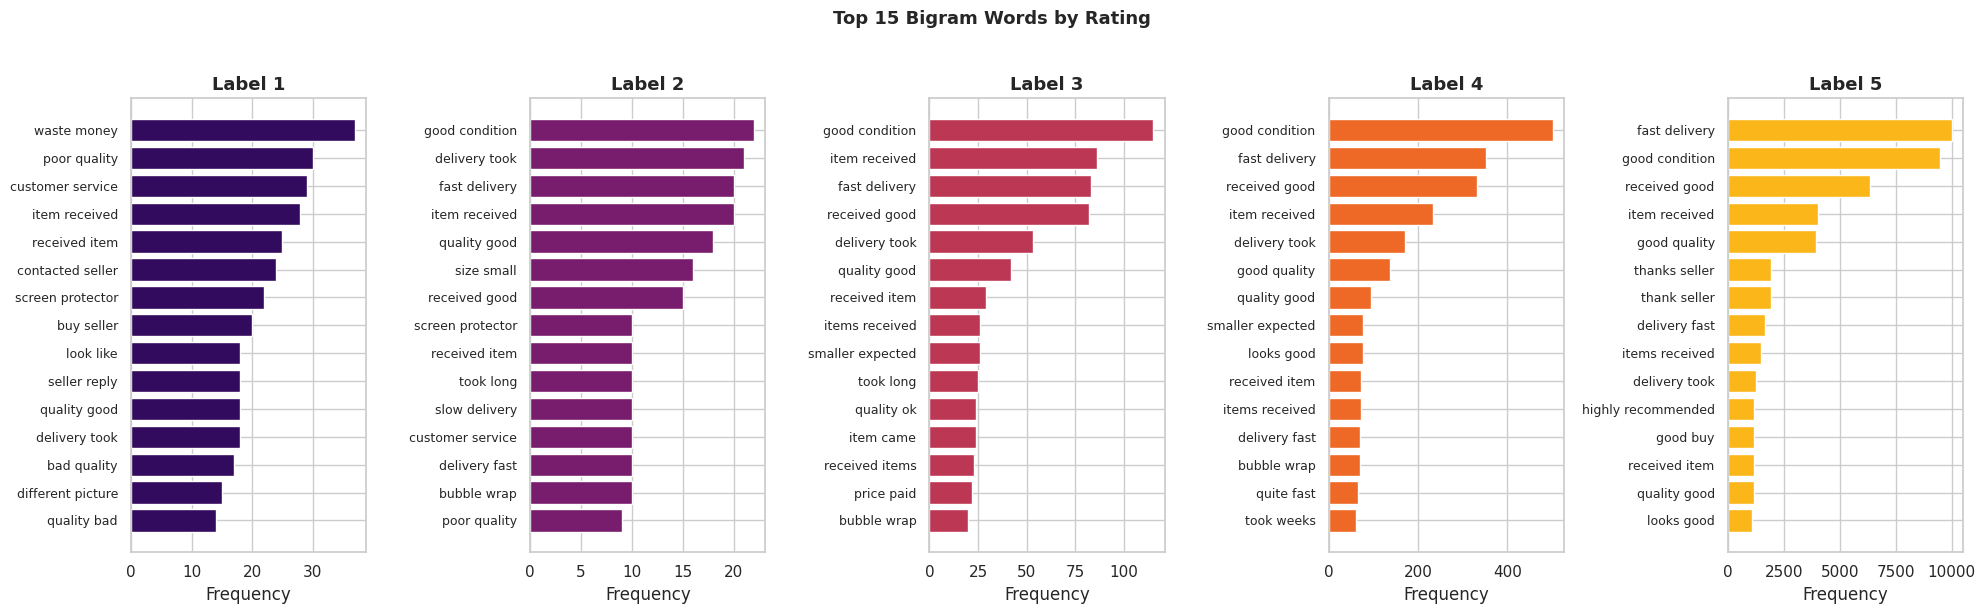

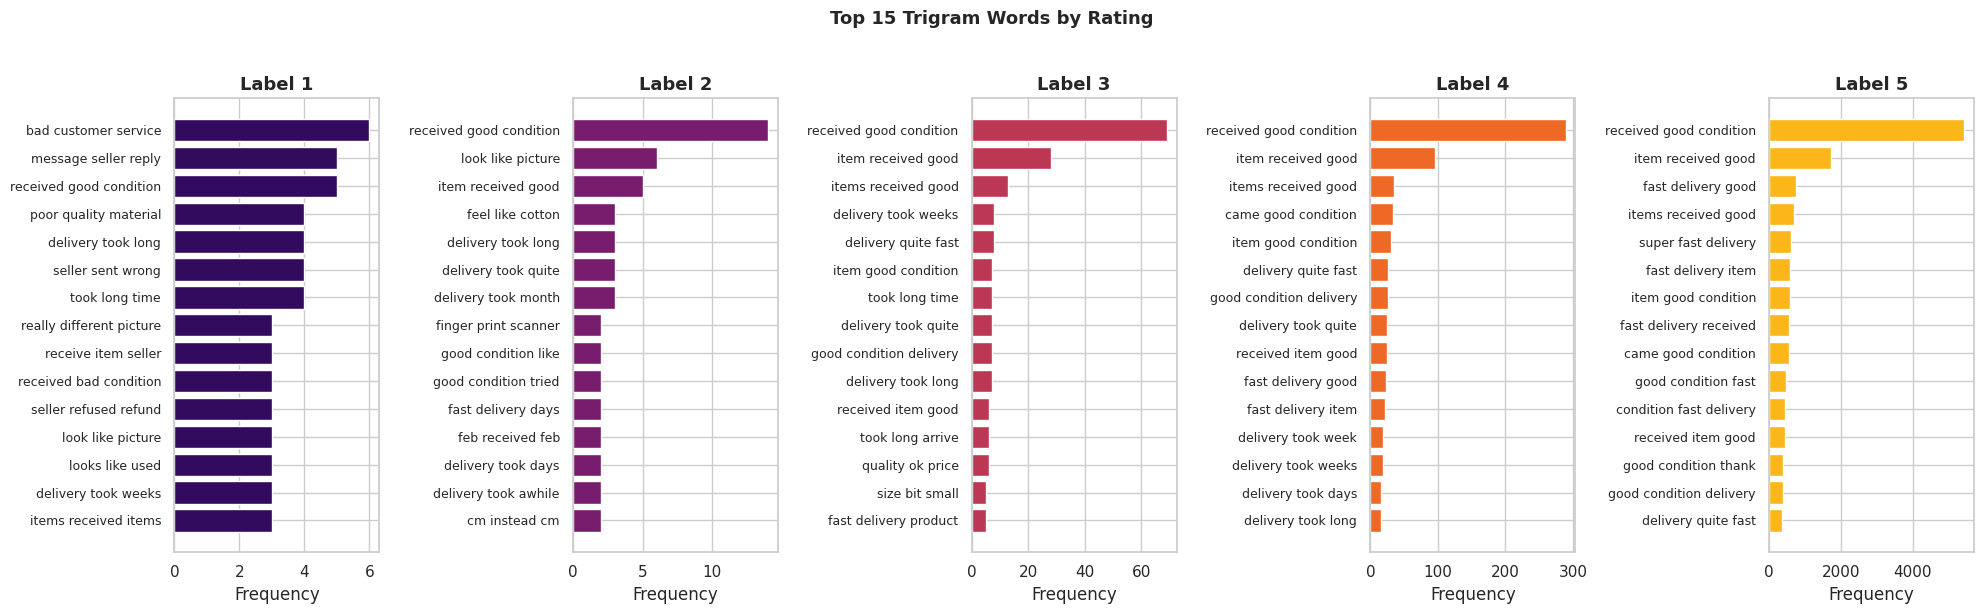

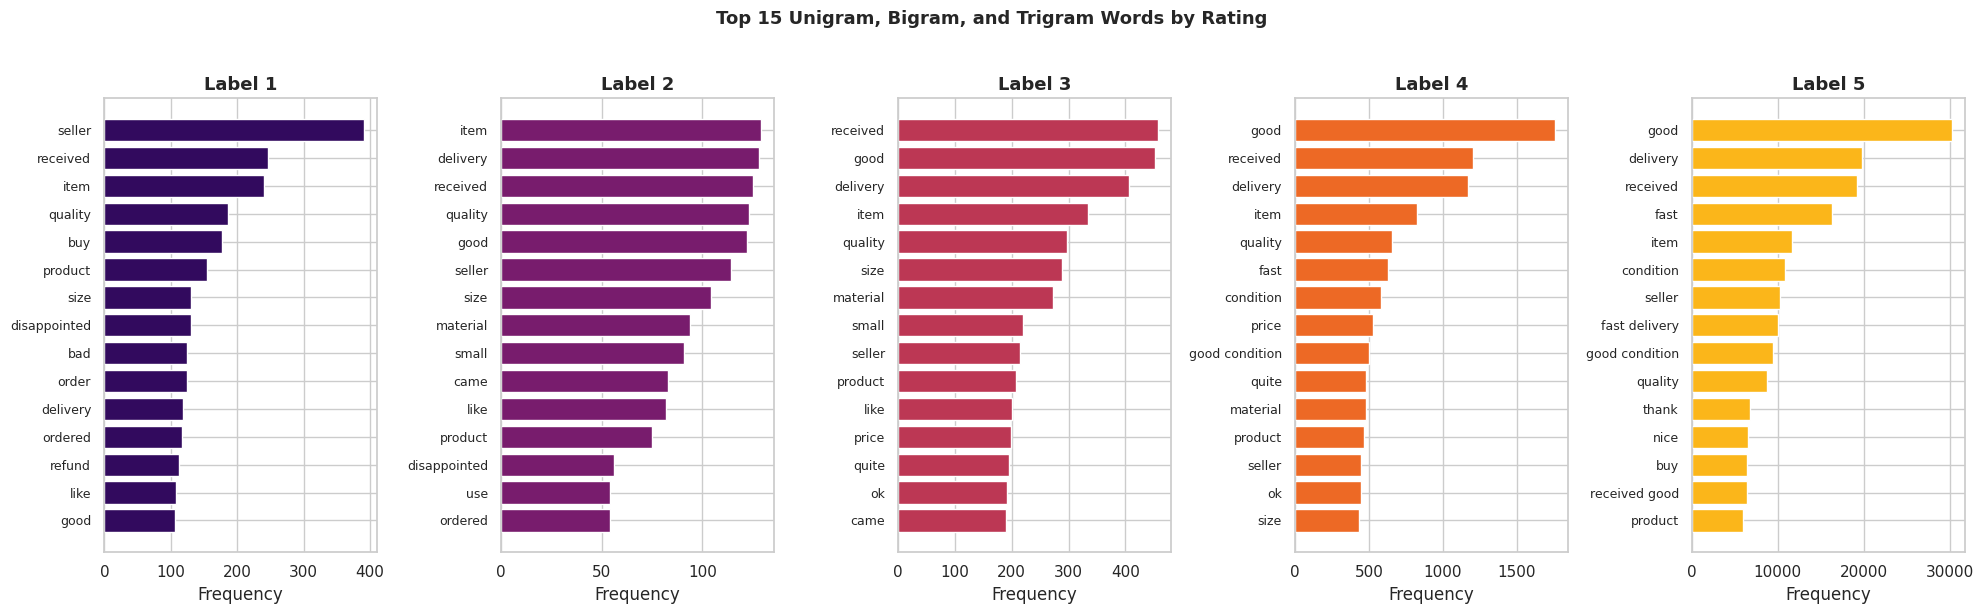

In [30]:
# Unigram
plot_top_words_by_label(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, top_n=15, ngram_range=(1,1))

# Bigram
plot_top_words_by_label(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, top_n=15, ngram_range=(2,2))

# Trigram
plot_top_words_by_label(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, top_n=15, ngram_range=(3,3))

# Unigram, Bigram, and Trigram combined
plot_top_words_by_label(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, top_n=15, ngram_range=(1,3))

# Data Splitting & Pipeline Architecture

In [31]:
df_train = X_train_features.copy()
df_train['label'] = y_train.values

df_test = X_test_features.copy()
df_test['label'] = y_test.values

from sklearn.model_selection import train_test_split

df_train, df_val, y_train, y_val = train_test_split(
    df_train,
    df_train['label'],
    test_size=0.1,
    random_state=42,
    stratify=df_train['label']
)

Machine Learning Pipelines

In [47]:
extractors = {
    "BoW (1-3 gram)": {
        "ext": CountVectorizer(ngram_range=(1, 3), max_features=10000),
        "scaler": MaxAbsScaler()
    },
    "TF-IDF (1-3 gram)": {
        "ext": TfidfVectorizer(ngram_range=(1, 3), max_features=10000),
        "scaler": MaxAbsScaler()
    },
    "Hybrid (TF-IDF + BERT)": {
        "ext": CombinedExtractor(max_features=5000),
        "scaler": MaxAbsScaler()
    }
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Naive Bayes": MultinomialNB()
}

experiments = {}

for ext_name, config in extractors.items():
    for mod_name, model in models.items():
        if ext_name == "Hybrid (TF-IDF + BERT)" and mod_name == "NaiveBayes":
            continue

        if mod_name == "Naive Bayes" and ("BERT" in ext_name or "Hybrid" in ext_name):
            continue

        experiments[f"{ext_name} + {mod_name} (Class Weights)"] = SklearnPipeline(
            extractor=config["ext"],
            model=model,
            text_col='text' if "BERT" in ext_name else 'processed_text',
            scaler=config["scaler"]
        )

Deep learning Pipelines

In [33]:
MAX_LEN = 128
EPOCHS = 3
BATCH_SIZE_LSTM = 32
BATCH_SIZE_BERT = 16

dl_experiments = {}

dl_experiments[f"LSTM Deep Learning "] = LSTMPipeline(
    max_vocab=15000,
    max_len=MAX_LEN,
    text_col='text',
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_LSTM
)

dl_experiments[f"DistilBERT Fine-Tuning "] = TFBERTPipeline(
    model_name='distilbert-base-uncased',
    max_len=MAX_LEN,
    text_col='text',
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_BERT
)

Feature embeddings

In [34]:
from sentence_transformers import SentenceTransformer
import numpy as np
import os

print("Đang tải mô hình SentenceTransformer...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print("Đang trích xuất Embeddings...")
X_train_emb = embedder.encode(df_train['text'].tolist(), show_progress_bar=True)
X_val_emb   = embedder.encode(df_val['text'].tolist(), show_progress_bar=True)
X_test_emb  = embedder.encode(df_test['text'].tolist(), show_progress_bar=True)

y_train_lbl = df_train['label'].values
y_val_lbl   = df_val['label'].values
y_test_lbl  = df_test['label'].values

os.makedirs('../features', exist_ok=True)
np.save('../features/X_train_emb.npy', X_train_emb)
np.save('../features/X_val_emb.npy', X_val_emb)
np.save('../features/X_test_emb.npy', X_test_emb)

np.save('../features/y_train_lbl.npy', y_train_lbl)
np.save('../features/y_val_lbl.npy', y_val_lbl)
np.save('../features/y_test_lbl.npy', y_test_lbl)

print("Đã lưu thành công các file embeddings (.npy) vào thư mục ../features/")

Đang tải mô hình SentenceTransformer...
Đang trích xuất Embeddings...


Batches:   0%|          | 0/2170 [00:00<?, ?it/s]

Batches:   0%|          | 0/242 [00:00<?, ?it/s]

Batches:   0%|          | 0/603 [00:00<?, ?it/s]

Đã lưu thành công các file embeddings (.npy) vào thư mục ../features/


In [48]:
import time
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, f1_score

results_list = []

# Load file Embeddings
print("Đang tải file Embeddings (.npy)...")
X_train_emb = np.load('../features/X_train_emb.npy')
y_train_emb = np.load('../features/y_train_lbl.npy')
X_test_emb  = np.load('../features/X_test_emb.npy')
y_test_emb  = np.load('../features/y_test_lbl.npy')

print("\n===== 1. SKLEARN PIPELINES =====")
for ext_name, config in extractors.items():
    for mod_name, model in models.items():

        if mod_name == "Naive Bayes" and ("BERT" in ext_name or "Hybrid" in ext_name):
            print(f"\n[Bỏ qua] {ext_name} + {mod_name} (MultinomialNB không nhận vector âm)")
            continue

        exp_name = f"{ext_name} + {mod_name}"
        print(f"\n[Running] {exp_name}")

        pipeline = SklearnPipeline(
            extractor=config["ext"],
            model=model,
            text_col='text' if ("BERT" in ext_name or "Hybrid" in ext_name) else 'processed_text',
            scaler=config["scaler"]
        )

        start_time = time.time()
        pipeline.fit(df_train, y_train, df_val, y_val)
        train_time = time.time() - start_time

        # Predict & Evaluate
        y_pred = pipeline.predict(df_test)
        f1_mac = f1_score(y_test, y_pred, average='macro')

        # Lưu kết quả
        results_list.append({
            'Tổ hợp Model': exp_name,
            'F1_Macro': f1_mac,
            'Thời gian Train (s)': train_time
        })

Đang tải file Embeddings (.npy)...

===== 1. SKLEARN PIPELINES =====

[Running] BoW (1-3 gram) + Logistic Regression

[Running] BoW (1-3 gram) + Naive Bayes

[Running] TF-IDF (1-3 gram) + Logistic Regression

[Running] TF-IDF (1-3 gram) + Naive Bayes

[Running] Hybrid (TF-IDF + BERT) + Logistic Regression

[Bỏ qua] Hybrid (TF-IDF + BERT) + Naive Bayes (MultinomialNB không nhận vector âm)


In [49]:
print("\n===== 2. FILE EMBEDDINGS (.npy) TRAINING =====")
models_on_embeddings = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Naive Bayes": GaussianNB()
}

for mod_name, model in models_on_embeddings.items():
    exp_name = f"BERT Embeddings + {mod_name}"
    print(f"\n[Running] {exp_name}")

    start_time = time.time()
    model.fit(X_train_emb, y_train_emb)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test_emb)
    f1_mac = f1_score(y_test_emb, y_pred, average='macro')

    results_list.append({
        'Tổ hợp Model': exp_name,
        'F1_Macro': f1_mac,
        'Thời gian Train (s)': train_time
    })


===== 2. FILE EMBEDDINGS (.npy) TRAINING =====

[Running] BERT Embeddings + Logistic Regression

[Running] BERT Embeddings + Naive Bayes


In [ ]:
print("\n===== 3. DEEP LEARNING PIPELINES =====")

# LƯU Ý: Vòng lặp bây giờ duyệt qua `dl_experiments` thay vì `experiments`
for exp_name, pipeline in dl_experiments.items():
    print(f"\n[Running] {exp_name}")

    start_time = time.time()
    pipeline.fit(df_train, y_train, df_val, y_val)
    train_time = time.time() - start_time

    y_pred = pipeline.predict(df_test)
    f1_mac = f1_score(y_test, y_pred, average='macro')

    # Nối tiếp kết quả vào results_list (đã chứa sẵn kết quả của ML trước đó)
    results_list.append({
        'Tổ hợp Model': exp_name,
        'F1_Macro': f1_mac,
        'Thời gian Train (s)': train_time
    })

# ==========================================
# TỔNG HỢP VÀ HIỂN THỊ KẾT QUẢ
# ==========================================
df_results = pd.DataFrame(results_list)
df_results = df_results.sort_values(by='F1_Macro', ascending=False).reset_index(drop=True)

print("\n===== HOÀN THÀNH HUẤN LUYỆN =====")
display(df_results)


===== 3. DEEP LEARNING PIPELINES =====

[Running] LSTM Deep Learning 
Epoch 1/3
2170/2170 [==============================] - 57s 22ms/step - loss: 1.3138 - accuracy: 0.6522 - val_loss: 0.7899 - val_accuracy: 0.7123
Epoch 2/3
2170/2170 [==============================] - 29s 14ms/step - loss: 1.0926 - accuracy: 0.6925 - val_loss: 0.9274 - val_accuracy: 0.6415
Epoch 3/3
2170/2170 [==============================] - 27s 13ms/step - loss: 0.9153 - accuracy: 0.7112 - val_loss: 0.8650 - val_accuracy: 0.6621


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.



[Running] DistilBERT Fine-Tuning 
Đang Tokenize dữ liệu cho HuggingFace...


tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_transform', 'activation_13', 'vocab_layer_norm', 'vocab_projector']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-

Epoch 1/3
4340/4340 [==============================] - 992s 223ms/step - loss: 1.1862 - accuracy: 0.6927 - val_loss: 0.7265 - val_accuracy: 0.7350
Epoch 2/3
3030/4340 [===================>..........] - ETA: 4:41 - loss: 1.0122 - accuracy: 0.7226

In [ ]:
import re

sns.set_theme(style="whitegrid")

# =====================================================================
# 1. BAR PLOT: So sánh F1-Macro Score của tất cả các tổ hợp
# =====================================================================
plt.figure(figsize=(14, 8))

# Đổi palette sang 'inferno'
ax = sns.barplot(
    data=df_results,
    x='F1_Macro',
    y='Tổ hợp Model',
    palette='inferno'
)

plt.title('So sánh F1-Macro Score của tất cả các tổ hợp mô hình', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('F1-Macro Score', fontsize=12)
plt.ylabel('', fontsize=12) # Ẩn tên trục y cho gọn
plt.xlim(0, 1.1) # Mở rộng trục x một chút để có chỗ in text

# Gắn số liệu cụ thể lên từng thanh bar
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.01,
        p.get_y() + p.get_height() / 2,
        f'{width:.4f}',
        ha='left',
        va='center',
        fontsize=11,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# =====================================================================
# 2. XỬ LÝ DỮ LIỆU ĐỂ VẼ BOX PLOT
# =====================================================================
def extract_feature_method(exp_name):
    # Xóa số thứ tự (VD: "1. ")
    name = re.sub(r'^\d+\.\s*', '', exp_name)

    # Nếu là ML truyền thống (có dấu +)
    if ' + ' in name:
        return name.split(' + ')[0].strip()
    # Nếu là Deep Learning (lấy phần trước dấu ngoặc đơn)
    else:
        return name.split(' (')[0].strip()

# Tạo cột mới chứa tên nhóm phương pháp
df_results['Nhóm phương pháp'] = df_results['Tổ hợp Model'].apply(extract_feature_method)


# =====================================================================
# 3. BOX PLOT: Phân phối F1-score giữa các phương pháp trích xuất
# =====================================================================
plt.figure(figsize=(12, 6))

# Vẽ Boxplot chính, đổi palette sang 'inferno'
sns.boxplot(
    data=df_results,
    x='Nhóm phương pháp',
    y='F1_Macro',
    palette='inferno',
    showfliers=False # Tắt các điểm ngoại lai của boxplot vì ta sẽ vẽ stripplot đè lên
)

# Chấm thêm các điểm tròn (stripplot) thể hiện từng mô hình cụ thể bên trong Box
sns.stripplot(
    data=df_results,
    x='Nhóm phương pháp',
    y='F1_Macro',
    color='black',
    alpha=0.7,
    size=8,
    jitter=True
)

plt.title('Phân phối F1-Macro Score theo Phương pháp trích xuất đặc trưng', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Phương pháp / Kiến trúc', fontsize=12, fontweight='bold')
plt.ylabel('F1-Macro Score', fontsize=12, fontweight='bold')
plt.xticks(rotation=15) # Nghiêng nhãn trục x một chút nếu tên quá dài

plt.tight_layout()
plt.show()